# 04 — Train a Model

End-to-end training of a **Transformer** or **Mamba** model on Levine32 CyTOF token sequences, all inside the notebook.

Steps covered:
1. Load dataset (PyCytoData or cached `.h5ad`)
2. Preprocess
3. Create splits
4. Tokenise sequences
5. Build vocabulary
6. Construct DataLoaders
7. Build model
8. Train with early stopping
9. Plot training curves
10. Quick embedding quality check (ARI / NMI / kNN purity)

All artefacts are saved to `outputs/{EXP_ID}/` in the same format as the CLI scripts.

## 0. Configuration

Edit the variables below to choose architecture, tokenisation scheme, and training budget.

In [14]:
# ── User-editable settings ─────────────────────────────────────────────────
MODEL_TYPE   = 'mamba'   # 'transformer' or 'mamba'
SCHEME       = 'rank_only'     # 'rank_only', 'strength_only', or 'hybrid'
MAX_EPOCHS   = 30              # reduce for a quick smoke-test
PATIENCE     = 5               # early-stopping patience
BATCH_SIZE   = 128
LR           = 3e-4
D_MODEL      = 128
N_LAYERS     = 3
# ───────────────────────────────────────────────────────────────────────────

## 1. Imports & Paths

In [15]:
import sys
import datetime
from functools import partial
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()   # MambaC2S/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from src.data.loader       import load_levine32, load_processed
from src.data.preprocessing import preprocess_from_config
from src.data.splits        import load_manifest, apply_splits, make_splits
from src.data.tokenization  import tokenize_cells
from src.data.vocab         import Vocabulary
from src.models             import build_model
from src.training.trainer   import Trainer, CellSequenceDataset
from src.evaluation.metrics import extract_embeddings, compute_embedding_metrics
from src.utils.config       import load_config, save_config
from src.utils.logging      import setup_logging
from src.utils.reproducibility import set_seed, resolve_device, log_environment

setup_logging()
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
print('Project root :', PROJECT_ROOT)
print('PyTorch      :', torch.__version__)

Project root : /Users/ronguy/Dropbox/Work/CyTOF/Experiments/MambaC2S
PyTorch      : 2.9.1


## 2. Load Base Config & Set Up Experiment

In [16]:
cfg = load_config(PROJECT_ROOT / 'configs' / 'base.yaml')

# Apply notebook overrides
cfg['model']['type']      = MODEL_TYPE
cfg['model']['d_model']   = D_MODEL
cfg['model']['n_layers']  = N_LAYERS
cfg['tokenization']['scheme'] = SCHEME
cfg['training']['max_epochs'] = MAX_EPOCHS
cfg['training']['patience']   = PATIENCE
cfg['training']['batch_size'] = BATCH_SIZE
cfg['training']['lr']         = LR

SEED = cfg['seed']
set_seed(SEED)

device = resolve_device(cfg.get('device', 'mps'))
print(f'Device : {device}')

# Experiment ID and output directory
ts     = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
EXP_ID = f'{MODEL_TYPE}_{SCHEME}_{ts}'
OUTPUT_DIR = PROJECT_ROOT / cfg['output']['output_dir'] / EXP_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Experiment : {EXP_ID}')
print(f'Output dir : {OUTPUT_DIR}')

save_config(cfg, OUTPUT_DIR / 'config_resolved.yaml')
log_environment(OUTPUT_DIR)

2026-04-04 12:20:30  INFO      src.utils.reproducibility — Random seed set to 42.
2026-04-04 12:20:30  INFO      src.utils.reproducibility — Auto-selected device: mps
Device : mps
Experiment : mamba_rank_only_20260404_122030
Output dir : /Users/ronguy/Dropbox/Work/CyTOF/Experiments/MambaC2S/outputs/mamba_rank_only_20260404_122030
2026-04-04 12:20:30  INFO      src.utils.reproducibility — Environment metadata saved to /Users/ronguy/Dropbox/Work/CyTOF/Experiments/MambaC2S/outputs/mamba_rank_only_20260404_122030/environment.json.


/Users/ronguy/Dropbox/Work/CyTOF/Experiments/MambaC2S/src/utils/reproducibility.py:55: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  try:


{'python': '3.11.9 (v3.11.9:de54cf5be3, Apr  2 2024, 07:12:50) [Clang 13.0.0 (clang-1300.0.29.30)]',
 'platform': 'macOS-26.3.1-arm64-arm-64bit',
 'pytorch': '2.9.1',
 'numpy': '1.26.4',
 'mps_available': True,
 'mps_built': True,
 'anndata': '0.12.5',
 'fcsparser': '0.2.8',
 'umap': '0.5.11',
 'sklearn': '1.7.2'}

## 3. Load Dataset

In [17]:
DATA_DIR     = PROJECT_ROOT / cfg['dataset']['data_dir']
DATASET_NAME = cfg['dataset']['dataset_name']
LABEL_COL    = cfg['dataset']['label_col']
PREP_CFG     = cfg['preprocessing']

processed_path = DATA_DIR / f'{DATASET_NAME}_processed.h5ad'

if processed_path.exists():
    print(f'Loading pre-processed data from {processed_path} ...')
    df = load_processed(processed_path, label_col=LABEL_COL)
else:
    print('Loading via PyCytoData and preprocessing on the fly ...')
    print('(Run scripts/prepare_data.py once to cache the processed file.)')
    df_raw = load_levine32(force_download=True)
    df, _  = preprocess_from_config(df_raw, PREP_CFG)

print(f'Loaded {len(df):,} cells')

Loading via PyCytoData and preprocessing on the fly ...
(Run scripts/prepare_data.py once to cache the processed file.)
2026-04-04 12:20:34  INFO      src.data.loader — Loading Levine32 via PyCytoData (force_download=True) ...


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fcsparser/api.py:490: UserWarning: The default channel names (defined by the $PnS parameter in the FCS file) were not unique. To avoid problems in downstream analysis, the channel names have been switched to the alternate channel names defined in the FCS file. To avoid seeing this warning message, explicitly instruct the FCS parser to use the alternate channel names by specifying the channel_naming parameter.
  warnings.warn(msg)


2026-04-04 12:20:34  INFO      src.data.loader — PyCytoData loaded Levine32: 265627 cells × 32 markers.
2026-04-04 12:20:34  INFO      src.data.loader — Loaded 265627 cells with 32 markers.
2026-04-04 12:20:34  INFO      src.data.loader — Cells: 104184 labeled, 161443 unlabeled (265627 total).
2026-04-04 12:20:34  INFO      src.data.preprocessing — Applied arcsinh transform (cofactor=5.0).
2026-04-04 12:20:34  INFO      src.data.preprocessing — Applied z-score normalization per marker.
2026-04-04 12:20:35  INFO      src.data.preprocessing — Computed within-cell ranks for 32 markers.
2026-04-04 12:20:35  INFO      src.data.preprocessing — Binned markers into 3 strength bins: ['LOW', 'MED', 'HIGH'].
Loaded 265,627 cells


## 4. Splits

In [18]:
manifest_path = DATA_DIR / 'split_manifest.json'

if manifest_path.exists():
    print(f'Loading splits from {manifest_path} ...')
    splits    = load_manifest(manifest_path)
    split_dfs = apply_splits(df, splits)
else:
    print('No manifest found — creating in-memory splits ...')
    sp = cfg['splits']
    splits = make_splits(
        df,
        labeled_train=sp['labeled_train'],
        labeled_val=sp['labeled_val'],
        labeled_test=sp['labeled_test'],
        unlabeled_train=sp['unlabeled_train'],
        unlabeled_val=sp['unlabeled_val'],
        seed=SEED,
        manifest_path=OUTPUT_DIR / 'split_manifest.json',
    )
    split_dfs = apply_splits(df, splits)

import shutil, json
# Copy manifest into experiment dir for reproducibility
dest = OUTPUT_DIR / 'split_manifest.json'
if manifest_path.exists() and not dest.exists():
    shutil.copy(manifest_path, dest)

train_df = split_dfs['train']
val_df   = split_dfs['val_self_supervised']
eval_df  = split_dfs['val_downstream']

print(f'train            : {len(train_df):>8,} cells')
print(f'val (self-sup)   : {len(val_df):>8,} cells')
print(f'val (downstream) : {len(eval_df):>8,} cells')

No manifest found — creating in-memory splits ...
2026-04-04 12:20:37  INFO      src.data.splits — Splitting 104184 labeled + 161443 unlabeled cells (seed=42).
2026-04-04 12:20:37  INFO      src.data.splits — Split summary:
2026-04-04 12:20:37  INFO      src.data.splits —   labeled_train                 : 62510 cells
2026-04-04 12:20:37  INFO      src.data.splits —   labeled_val                   : 20837 cells
2026-04-04 12:20:37  INFO      src.data.splits —   labeled_test                  : 20837 cells
2026-04-04 12:20:37  INFO      src.data.splits —   unlabeled_train               : 145298 cells
2026-04-04 12:20:37  INFO      src.data.splits —   unlabeled_val                 : 16145 cells
2026-04-04 12:20:37  INFO      src.data.splits —   train                         : 207808 cells
2026-04-04 12:20:37  INFO      src.data.splits —   val_self_supervised           : 16145 cells
2026-04-04 12:20:37  INFO      src.data.splits —   val_downstream                : 20837 cells
2026-04-04 12:

## 5. Tokenise & Build Vocabulary

In [19]:
print(f'Tokenising with scheme = {SCHEME!r} ...')

train_seqs = tokenize_cells(train_df, scheme=SCHEME)
val_seqs   = tokenize_cells(val_df,   scheme=SCHEME)
eval_seqs  = tokenize_cells(eval_df,  scheme=SCHEME)

print(f'  train sequences : {len(train_seqs):,}  (avg len {sum(len(s) for s in train_seqs)/len(train_seqs):.1f} tokens)')
print(f'  val sequences   : {len(val_seqs):,}')

# Build vocabulary from training sequences only
vocab_path = OUTPUT_DIR / 'vocab.json'
if vocab_path.exists():
    vocab = Vocabulary.load(vocab_path)
    print(f'Loaded vocab: {len(vocab)} tokens')
else:
    vocab = Vocabulary()
    vocab.build(train_seqs)
    vocab.save(vocab_path)
    print(f'Built vocab: {len(vocab)} tokens  →  saved to {vocab_path}')

train_ids = [vocab.encode(s) for s in train_seqs]
val_ids   = [vocab.encode(s) for s in val_seqs]
eval_ids  = [vocab.encode(s) for s in eval_seqs]

Tokenising with scheme = 'rank_only' ...
2026-04-04 12:20:40  INFO      src.data.tokenization — Tokenizing 207808 cells with scheme='rank_only', 32 markers.
2026-04-04 12:20:40  INFO      src.data.tokenization — Tokenizing 16145 cells with scheme='rank_only', 32 markers.
2026-04-04 12:20:40  INFO      src.data.tokenization — Tokenizing 20837 cells with scheme='rank_only', 32 markers.
  train sequences : 207,808  (avg len 34.0 tokens)
  val sequences   : 16,145
2026-04-04 12:20:41  INFO      src.data.vocab — Built vocabulary: 4 special + 32 regular = 36 total tokens.
2026-04-04 12:20:41  INFO      src.data.vocab — Vocabulary saved to /Users/ronguy/Dropbox/Work/CyTOF/Experiments/MambaC2S/outputs/mamba_rank_only_20260404_122030/vocab.json (36 tokens).
Built vocab: 36 tokens  →  saved to /Users/ronguy/Dropbox/Work/CyTOF/Experiments/MambaC2S/outputs/mamba_rank_only_20260404_122030/vocab.json


## 6. DataLoaders

In [20]:
MAX_SEQ = cfg['model']['max_seq_len']
PAD_ID  = vocab.pad_id

collate = partial(CellSequenceDataset.collate_fn, pad_id=PAD_ID)

train_ds = CellSequenceDataset(train_ids, pad_id=PAD_ID, max_seq_len=MAX_SEQ)
val_ds   = CellSequenceDataset(val_ids,   pad_id=PAD_ID, max_seq_len=MAX_SEQ)
eval_ds  = CellSequenceDataset(eval_ids,  pad_id=PAD_ID, max_seq_len=MAX_SEQ)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate, num_workers=0)
eval_loader  = DataLoader(eval_ds,  batch_size=256,        shuffle=False,
                          collate_fn=collate, num_workers=0)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')

Train batches : 1624
Val batches   : 127


## 7. Build Model

In [21]:
model = build_model(cfg, vocab_size=len(vocab))
model.to(device)

n_params = model.count_parameters()
print(f'Model    : {model.__class__.__name__}')
print(f'Params   : {n_params:,}')
print(f'Device   : {device}')
print(model)

Model    : SimpleMambaLM
Params   : 343,552
Device   : mps
SimpleMambaLM(vocab_size=36, d_model=128, params=343,552)


## 8. Train

In [22]:
tr_cfg = cfg['training']

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    output_dir=OUTPUT_DIR,
    lr=tr_cfg['lr'],
    weight_decay=tr_cfg['weight_decay'],
    max_epochs=tr_cfg['max_epochs'],
    patience=tr_cfg['patience'],
    grad_clip=tr_cfg['grad_clip'],
    mixed_precision=tr_cfg.get('mixed_precision', False),
    device=device,
    pad_id=PAD_ID,
)

results = trainer.train()

print(f'\nBest val_loss : {results["best_val_loss"]:.4f}')
print(f'Best epoch    : {results["best_epoch"]} / {results["total_epochs"]}')
print(f'Checkpoint    : {results["checkpoint"]}')

2026-04-04 12:20:47  INFO      src.training.trainer — Starting training: max_epochs=30  patience=5  device=mps
2026-04-04 12:21:16  INFO      src.utils.logging — Epoch metrics — epoch=1  lr=0.0003  train_loss=3.0331  val_loss=2.8937  val_perplexity=18.0597
2026-04-04 12:21:16  INFO      src.training.trainer — Epoch 1: val_loss improved to 2.8937 — checkpoint saved.
2026-04-04 12:21:47  INFO      src.utils.logging — Epoch metrics — epoch=2  lr=0.0003  train_loss=2.8282  val_loss=2.7687  val_perplexity=15.9380
2026-04-04 12:21:47  INFO      src.training.trainer — Epoch 2: val_loss improved to 2.7687 — checkpoint saved.
2026-04-04 12:22:17  INFO      src.utils.logging — Epoch metrics — epoch=3  lr=0.0003  train_loss=2.7198  val_loss=2.6519  val_perplexity=14.1805
2026-04-04 12:22:17  INFO      src.training.trainer — Epoch 3: val_loss improved to 2.6519 — checkpoint saved.
2026-04-04 12:22:46  INFO      src.utils.logging — Epoch metrics — epoch=4  lr=0.0003  train_loss=2.6005  val_loss=2.5

## 9. Training Curves

FileNotFoundError: [Errno 2] No such file or directory: '/Users/ronguy/Dropbox/Work/CyTOF/Experiments/MambaC2S/outputs/mamba_rank_only_20260404_122030/plots/training_curves.png'

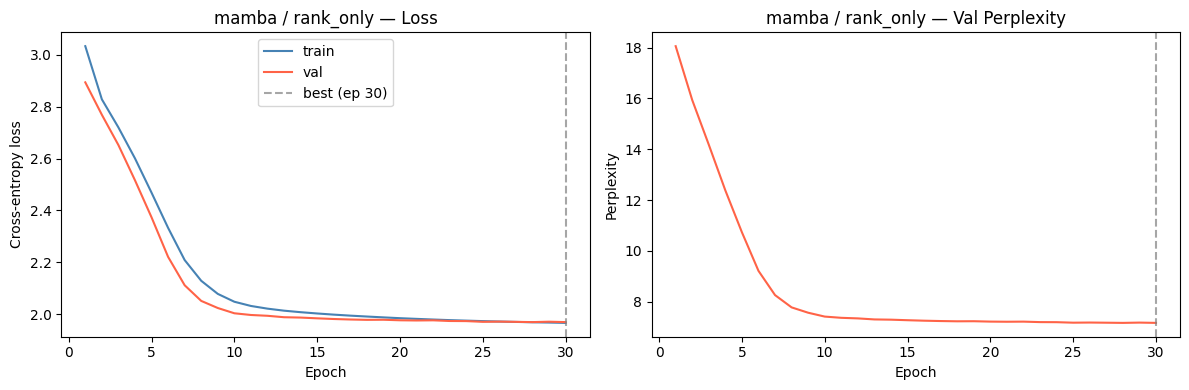

In [24]:
log_df = pd.read_csv(OUTPUT_DIR / 'training_log.csv')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(log_df['epoch'], log_df['train_loss'], label='train', color='steelblue')
axes[0].plot(log_df['epoch'], log_df['val_loss'],   label='val',   color='tomato')
axes[0].axvline(results['best_epoch'], color='gray', linestyle='--', alpha=0.7, label=f'best (ep {results["best_epoch"]})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title(f'{MODEL_TYPE} / {SCHEME} — Loss')
axes[0].legend()

# Perplexity
axes[1].plot(log_df['epoch'], log_df['val_perplexity'], color='tomato')
axes[1].axvline(results['best_epoch'], color='gray', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')
axes[1].set_title(f'{MODEL_TYPE} / {SCHEME} — Val Perplexity')

plt.tight_layout()
(OUTPUT_DIR / 'plots').mkdir(exist_ok=True)
fig.savefig(OUTPUT_DIR / 'plots' / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Final val loss: {log_df["val_loss"].iloc[-1]:.4f}  |  best: {results["best_val_loss"]:.4f}')

## 10. Quick Embedding Quality Check

Load the best checkpoint and evaluate embeddings on the labeled validation split.

In [25]:
# Reload best checkpoint weights into the model
checkpoint = torch.load(OUTPUT_DIR / 'best_checkpoint.pt', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f'Loaded checkpoint from epoch {checkpoint["epoch"]}  (val_loss={checkpoint["val_loss"]:.4f})')

Loaded checkpoint from epoch 30  (val_loss=1.9693)


In [26]:
pooling = cfg['evaluation']['embedding_pooling']
print(f'Extracting embeddings (pooling={pooling!r}) ...')

embeddings = extract_embeddings(model, eval_loader, device=device, pooling=pooling)
print(f'Embeddings shape: {embeddings.shape}')

# Save
emb_dir = OUTPUT_DIR / 'embeddings'
emb_dir.mkdir(exist_ok=True)
np.save(emb_dir / 'val_downstream_embeddings.npy', embeddings)
print(f'Saved to {emb_dir / "val_downstream_embeddings.npy"}')

Extracting embeddings (pooling='mean') ...
Embeddings shape: (20837, 128)
Saved to /Users/ronguy/Dropbox/Work/CyTOF/Experiments/MambaC2S/outputs/mamba_rank_only_20260404_122030/embeddings/val_downstream_embeddings.npy


In [27]:
labels = eval_df[LABEL_COL].tolist()

metrics = compute_embedding_metrics(
    embeddings, labels,
    knn_k=cfg['evaluation']['knn_k'],
    seed=SEED,
)

print(f'\nEmbedding quality ({MODEL_TYPE} / {SCHEME})')
print(f'  ARI        : {metrics["ARI"]:.4f}')
print(f'  NMI        : {metrics["NMI"]:.4f}')
print(f'  kNN purity : {metrics["knn_purity"]:.4f}')

# Save metrics
import json
metrics_dir = OUTPUT_DIR / 'metrics'
metrics_dir.mkdir(exist_ok=True)
with open(metrics_dir / 'downstream.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'\nMetrics saved to {metrics_dir / "downstream.json"}')

TypeError: only length-1 arrays can be converted to Python scalars